In [2]:
import os

import numpy as np
from PIL import Image
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']      # 或者 'Microsoft YaHei'、'Arial Unicode MS' 等系统有的中文字体
plt.rcParams['axes.unicode_minus'] = False       # 解决负号显示问题
import glob

In [4]:
def gaussian2D(coords, A, x0, y0, wx, wy, offset):
    x, y = coords
    xo = float(x0)
    yo = float(y0)
    g = offset + A*np.exp( - 2*(x-xo)**2/wx**2 - 2*(y-yo)**2/wy**2 )
    return g.ravel()
 # a = ((x)**2)/(4*sigma_x**2)

In [22]:
xs = []
ys = []
idx = []

for i in range(200):
    filename = f"关分子泵前/{i}.bmp"
    try:
        im = Image.open(filename).convert('L')
    except (FileNotFoundError, OSError):
        print(f"无法读取 {filename}")
        continue

    img = np.array(im, dtype=float)  # 转成 numpy 数组
    y_dim, x_dim = img.shape
    x = np.linspace(0, x_dim-1, x_dim)
    y = np.linspace(0, y_dim-1, y_dim)
    x, y = np.meshgrid(x, y)

    initial_guess = (img.max(), x_dim/2, y_dim/2, x_dim/4, y_dim/4, 0, img.min())

    try:
        popt, _ = curve_fit(gaussian2D, (x, y), img.ravel(), p0=initial_guess)
        _, x0, y0, _, _, _, _ = popt
        xs.append(x0)
        ys.append(y0)
        idx.append(i)
    except RuntimeError:
        print(f"{filename} 拟合失败")

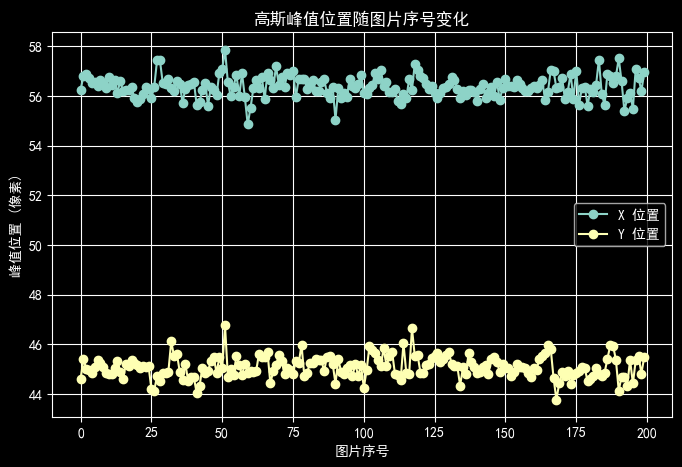

0.4311295230395896 0.4364831869430888


In [26]:
plt.figure(figsize=(8,5))
plt.plot(idx, xs, label='X 位置', marker='o')
plt.plot(idx, ys, label='Y 位置', marker='o')
plt.xlabel('图片序号')
plt.ylabel('峰值位置 (像素)')
plt.title('高斯峰值位置随图片序号变化')
plt.legend()
plt.grid(True)
plt.show()
print(np.std(xs),np.std(ys))

In [51]:
xs = []
ys = []
idx = []

for i in range(200):
    filename = f"关分子泵后/{i}.bmp"
    try:
        im = Image.open(filename).convert('L')
    except (FileNotFoundError, OSError):
        print(f"无法读取 {filename}")
        continue

    img = np.array(im, dtype=float)  # 转成 numpy 数组
    y_dim, x_dim = img.shape
    x = np.linspace(0, x_dim-1, x_dim)
    y = np.linspace(0, y_dim-1, y_dim)
    x, y = np.meshgrid(x, y)

    initial_guess = (img.max(), x_dim/2, y_dim/2, x_dim/4, y_dim/4, img.min())

    try:
        popt, _ = curve_fit(gaussian2D, (x, y), img.ravel(), p0=initial_guess)
        print(popt[3]*1.85,popt[4]*1.85)
        _, x0, y0, _, _,  _ = popt
        xs.append(x0)
        ys.append(y0)
        idx.append(i)
    except RuntimeError:
        print(f"{filename} 拟合失败")

29.87171233456482 28.412853345978785
29.764983161164068 28.49910382379554
29.747753274682925 28.473349791459192
29.78157668724421 28.419768330047514
29.672544463375683 28.399455342519346
29.753384306226536 28.398165576528832
29.798461446814525 28.42939647736339
29.751434570431616 28.389533329521868
29.823773434539707 28.41656306460858
29.64483927901169 28.45174144591143
29.845325808478048 28.479552790021287
29.873340215825493 28.438334030533998
29.729222432037254 28.412410394606262
29.697557044822624 28.433163948170623
29.778340508790823 28.453247237685268
29.714211999864737 28.42875674333549
29.927876085754207 28.484475591891623
29.6811211534983 28.400555583062825
29.788974792780586 28.480565256554563
29.77181158169498 28.483773242143442
29.764884716932787 28.421553796362062
29.726030125241206 28.447695162046738
29.777951500622123 28.44097767001966
29.701125145034474 28.439616115814385
29.68548827229964 28.381622674735205
29.656171014679614 28.447268133553095
29.707659229584745 28.437

In [46]:
popt

array([ 7.57731701e+01,  5.08711613e+01,  5.95976008e+01, -7.94998143e+00,
        7.65378076e+00,  7.32459890e-02,  3.81737697e-02])

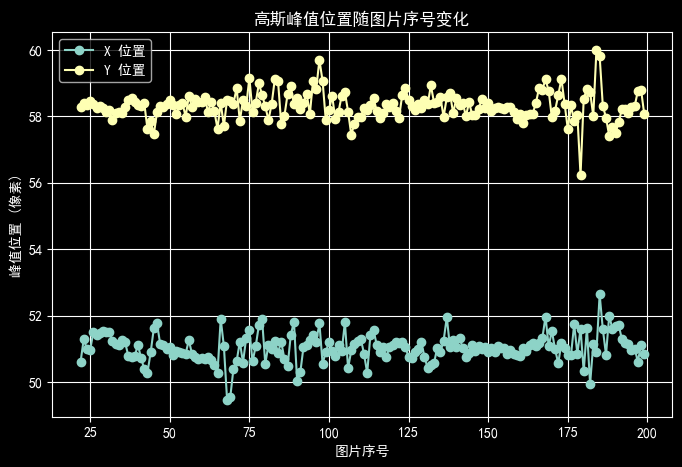

0.42702934752218585 0.41358048242002127


In [33]:
plt.figure(figsize=(8,5))
plt.plot(idx[22:], xs[22:], label='X 位置', marker='o')
plt.plot(idx[22:], ys[22:], label='Y 位置', marker='o')
plt.xlabel('图片序号')
plt.ylabel('峰值位置 (像素)')
plt.title('高斯峰值位置随图片序号变化')
plt.legend()
plt.grid(True)
plt.show()
print(np.std(xs),np.std(ys))

In [44]:
xs = []
ys = []
idx = []
for no,i in enumerate(os.listdir('3/')):
    filename = f"3/"+i
    try:
        im = Image.open(filename).convert('L')
    except (FileNotFoundError, OSError):
        print(f"无法读取 {filename}")
        continue

    img = np.array(im, dtype=float)  # 转成 numpy 数组
    y_dim, x_dim = img.shape
    x = np.linspace(0, x_dim-1, x_dim)
    y = np.linspace(0, y_dim-1, y_dim)
    x, y = np.meshgrid(x, y)

    initial_guess = (img.max(), x_dim/2, y_dim/2, x_dim/4, y_dim/4, 0, img.min())

    try:
        popt, _ = curve_fit(gaussian2D, (x, y), img.ravel(), p0=initial_guess)
        _, x0, y0, _, _, _, _ = popt
        xs.append(x0)
        ys.append(y0)
        idx.append(no)
    except RuntimeError:
        print(f"{filename} 拟合失败")

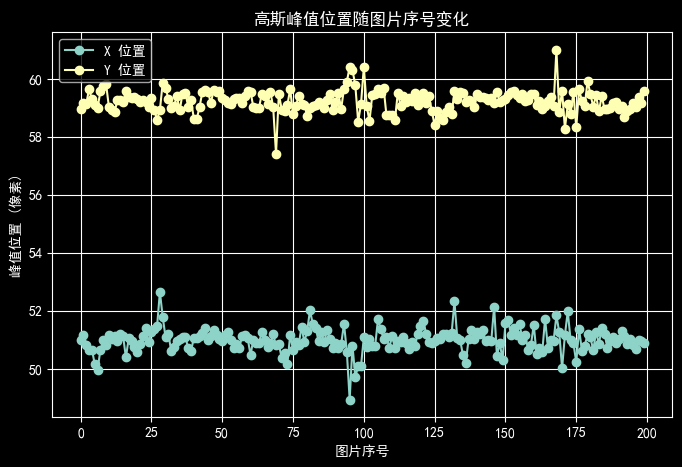

0.41914640340780396 0.38134568879324593


In [45]:

plt.figure(figsize=(8,5))
plt.plot(idx, xs, label='X 位置', marker='o')
plt.plot(idx, ys, label='Y 位置', marker='o')
plt.xlabel('图片序号')
plt.ylabel('峰值位置 (像素)')
plt.title('高斯峰值位置随图片序号变化')
plt.legend()
plt.grid(True)
plt.show()
print(np.std(xs),np.std(ys))

In [10]:
xs = []
ys = []
idx = []
folder='气浮/'
for no,i in enumerate(os.listdir(folder)):
    filename =folder+ i
    try:
        im = Image.open(filename).convert('L')
    except (FileNotFoundError, OSError):
        print(f"无法读取 {filename}")
        continue

    img = np.array(im, dtype=float)  # 转成 numpy 数组
    y_dim, x_dim = img.shape
    x = np.linspace(0, x_dim-1, x_dim)
    y = np.linspace(0, y_dim-1, y_dim)
    x, y = np.meshgrid(x, y)

    initial_guess = (img.max(), x_dim/2, y_dim/2, x_dim/4, y_dim/4, img.min())

    try:
        popt, _ = curve_fit(gaussian2D, (x, y), img.ravel(), p0=initial_guess)
        print(popt[3]*1.85,popt[4]*1.85)
        _, x0, y0, _, _,  _ = popt
        xs.append(x0)
        ys.append(y0)
        idx.append(no)
    except RuntimeError:
        print(f"{filename} 拟合失败")

28.97973463922628 28.24280878067375
28.918786214654745 28.205043585702725
29.032442459181702 28.218599719983633
29.168322281429656 28.23241955697897
29.089970860725405 28.2224197619464
29.084577266482103 28.29284128402826
29.03241467855576 28.216866380840916
29.039116210120376 28.257222905764475
29.058369378277593 28.317983815808645
29.021625114471025 28.319272448953583
29.159284649869726 28.21285247971805
29.073046519819766 28.194118115250323
29.039616475009637 28.29778062370061
29.012792598706376 28.249074981390752
29.120959941278983 28.29985937570296
29.075799342379945 28.300169398893942
29.128362123746093 28.297233394717747
29.162876806691557 28.313270485636753
29.23083357410719 28.269665514386183
29.128108984417235 28.35577765348816
29.11027184073957 28.29763099837645
29.127135694215163 28.255118895654764
29.128503297230576 28.30020325024341
29.063187132199236 28.29441420221012
29.08453987475027 28.23475481822779
29.131224925308327 28.279924747050895
29.134675647418298 28.28674030

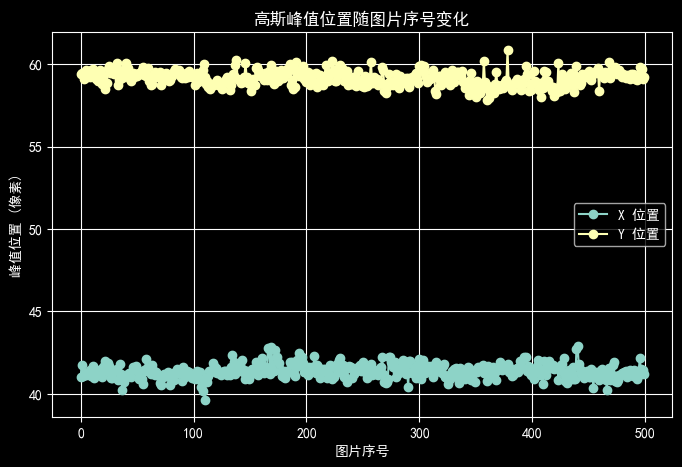

0.4053049513058942 0.4300898655735752


In [11]:

plt.figure(figsize=(8,5))
plt.plot(idx, xs, label='X 位置', marker='o')
plt.plot(idx, ys, label='Y 位置', marker='o')
plt.xlabel('图片序号')
plt.ylabel('峰值位置 (像素)')
plt.title('高斯峰值位置随图片序号变化')
plt.legend()
plt.grid(True)
plt.show()
print(np.std(xs),np.std(ys))